<a href="https://colab.research.google.com/github/stasianimborkar120707-rgb/Project-1/blob/main/Project%202%20cancer%20classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Starting Training ---
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.5746 - loss: 0.7019 - val_accuracy: 0.6304 - val_loss: 0.6297
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8117 - loss: 0.4537 - val_accuracy: 0.9130 - val_loss: 0.4102
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9120 - loss: 0.3248 - val_accuracy: 0.9565 - val_loss: 0.3046
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9242 - loss: 0.2564 - val_accuracy: 0.9565 - val_loss: 0.2484
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9340 - loss: 0.2176 - val_accuracy: 0.9783 - val_loss: 0.2144
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9413 - loss: 0.1921 - val_accuracy: 0.9783 - val_loss: 0.1908
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9438 - loss: 0.1738 - val_accuracy: 0.9783 - val_loss: 0.1734
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9487 - loss: 0.1600 

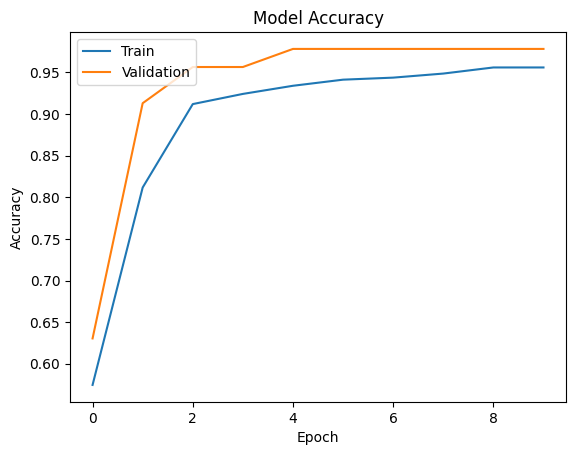

In [ ]:

import numpy as np
import pandas as pd
import sklearn.datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# 1. Load the Dataset from sklearn
# This dataset contains 30 features like radius, texture, and perimeter
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()
data_frame = pd.DataFrame(breast_cancer_dataset.data, columns=breast_cancer_dataset.feature_names)
data_frame['label'] = breast_cancer_dataset.target

# 2. Split Data into Features (X) and Target (Y)
X = data_frame.drop(columns='label', axis=1)
Y = data_frame['label']

# FIXED: Changed 'test_split' to 'test_size'
# This reserves 20% of data for testing the model's accuracy
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# 3. Standardize the data
# Neural networks perform much better when data is scaled (normalized)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# 4. Build the Neural Network
# We use an input layer (30 features), one hidden layer, and an output layer
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(30,)),
    keras.layers.Dense(20, activation='relu'),
    keras.layers.Dense(2, activation='sigmoid')
])

# 5. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 6. Train the Model
# We run the training for 10 epochs (passes through the data)
print("--- Starting Training ---")
history = model.fit(X_train_std, Y_train, epochs=10, validation_split=0.1, verbose=1)

# 7. Evaluate the Model on Test Data
print("\n--- Model Evaluation ---")
loss, accuracy = model.evaluate(X_test_std, Y_test)
print(f'Test Accuracy: {accuracy*100:.2f}%')

# 8. Visualizing Training Accuracy (Optional but good for submission)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()